# Fitting a single LicketyFit event

This notebook introduces the same configuration ideas used by `batch_fit_driver_wcte.py` and `batch_fit_driver_wcsim.py`, but runs them on one event at a time through `fit_single_event.py`.

The intended workflow is:

1. choose whether the event is WCTE/real-data-style or WCSim;
2. configure the same knobs used by the batch drivers;
3. fit one event;
4. inspect the fitted parameters, expected PEs/times, seed choice, and residuals;
5. iterate quickly before launching a large batch job.

`fit_single_event.py` intentionally reuses the batch-driver modules for the likelihood, seed scan, fixed-parameter handling, and retry/rescue logic. That means a one-event notebook study should behave like the corresponding batch-driver configuration.

## 1. Imports and paths

Place `fit_single_event.py` in the same directory as the two batch drivers, usually `scripts/`. If this notebook lives somewhere else, add that directory to `sys.path` below.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Update this if your notebook is not being run from the repository root.
REPO_ROOT = Path.cwd()
SCRIPTS_DIR = REPO_ROOT / "../scripts"

# If the notebook is already in scripts/, this still does no harm.
for p in [SCRIPTS_DIR, REPO_ROOT]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fit_single_event import (
    SingleEventConfig,
    load_wcte_selected_events,
    fit_single_event,
    fit_wcte_event,
    fit_wcsim_event,
    summarize_result,
    result_dataframe,
    plot_observed_vs_expected,
)

from plot_event import *

## 2. The core configuration object

The `SingleEventConfig` object mirrors the main settings in the batch drivers. The most important fields are:

| Field | Meaning |
|---|---|
| `data_kind` | `"wcte"` or `"wcsim"` |
| `fit_particle` | particle hypothesis, for example `"muon"`, `"pion"`, `"kaon"`, `"proton"` |
| `fit_mode` | `"full_length"` for the 7-parameter mode or `"absorption"` for the 8-parameter mode |
| `likelihood_mode` | `"charge_time"`, `"charge_only"`, or `"timing_only"` |
| `fixed_params` | dictionary of parameters to hold fixed, for example `{"z0": -1350.0, "ke0_mev": 1000.0}` |
| `wcte_n_root_entries_to_scan` | optional default raw ROOT entry scan count for WCTE selected-event loading |
| `wcte_selection_sample_fraction` | fraction of scanned entries used to estimate the T5 timing reference; `1.0` is safest for one-event studies |
| `fast_seed_*` | seed-grid controls matching the batch drivers |
| `ncall_migrad`, `max_fit_attempts`, `fcn_retry_threshold` | main Minuit/retry controls |

Leave a field as `None` to use the default from the chosen batch driver.

In [91]:
# A compact example configuration for quick interactive tests.
# Increase ncall_migrad and/or the seed grid once the setup looks sensible.
base_cfg = SingleEventConfig(
    data_kind="wcte",
    fit_particle="muon",
    fit_mode="full_length",
    likelihood_mode="charge_time",
    fixed_params={
        # Examples:
        # "z0": -1350.0,
        # "ke0_mev": 1500.0,  # absorption mode only; converted to full_range internally
    },
    ncall_migrad=20000,
    max_fit_attempts=2,
    fcn_retry_threshold=1100.0,
    save_top_n_seeds=10,
    verbose=True,
)
base_cfg

SingleEventConfig(data_kind='wcte', fit_particle='muon', fit_mode='full_length', likelihood_mode='charge_time', fixed_params={}, event_index=0, wcte_n_root_entries_to_scan=None, wcte_max_selected_events=None, wcte_loader_step_size=None, wcte_selection_sample_fraction=1.0, wcte_selection_max_sample_events=None, wcte_use_t5_hit_time=None, run=None, beam_p=None, event_source=None, user_event_file=None, user_event_key=None, user_event_apply_peak_window=None, particle_selection_label=None, selection_tof_ns=None, selection_tof_window_ns=None, selection_tof_field=None, selection_momentum_field=None, selection_t5_particle_nr=None, use_peak_time_cut=None, peak_window_ns=None, peak_bin_width_ns=None, config_root_file=None, allow_missing_good_pmts=None, wcsim_input_file=None, energy_true=None, wcsim_particle_label=None, wcsim_particle_dir=None, wcsim_pmt_id_mode=None, wcsim_wcte_mapping_path=None, wcsim_pmt_id_offset=None, geometry_path=None, geometry_file=None, table_dir=None, other_mpmt_info_pa

## 3. WCTE example: first load selected events from a run

For WCTE ROOT data, do **not** treat `event_index` as a raw ROOT entry. Many entries will not pass the beam/quality/TOF/timing cuts.

The recommended workflow is:

1. choose how many raw `WCTEReadoutWindows` entries to scan before cuts;
2. let the event loader tell you how many selected events passed cuts;
3. choose one selected event from that returned list;
4. pass that selected event directly to `fit_single_event`.

The selected event arrays have columns:

```text
column 0: WCTE PMT id = mPMT slot * 100 + PMT position
column 1: charge
column 2: calibrated hit time [ns]
column 3: raw ROOT entry index
```


In [94]:
wcte_cfg = SingleEventConfig(
    data_kind="wcte",
    run= 1580, #1589,
    fit_particle="muon",
    fit_mode="full_length",
    likelihood_mode="charge_time",
    particle_selection_label="muon",
    selection_t5_particle_nr=1,
    fixed_params={}, #{"ke0_mev": 773.2,"z0":-1348},
    # If the scalar ROOT fields are not enough to infer the TOF, provide it explicitly:
    # selection_tof_ns=...,
    # selection_tof_window_ns=0.2,

    # For single-event notebooks, use a reasonably broad T5-reference sample.
    # This prevents the "Could not estimate T5 delta peak time" error that can
    # happen when only a tiny number of raw ROOT entries are scanned.
    wcte_selection_sample_fraction=1.0,

    ncall_migrad=20000,
    max_fit_attempts=2,
    save_top_n_seeds=10,
    verbose=True,
)

selection = load_wcte_selected_events(
    wcte_cfg,
    n_root_entries=1000,
    max_selected_events=50,
)

# print("Number of events passing cuts:", selection["n_selected"])
# print("First selected ROOT entry indices:", selection["root_entry_indices"][:10])

PROCESSING ENTRIES: 1000
Selected-event loader
---------------------
Particle label:              muon
ROOT file:                   /eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/1580/WCTE_merged_production_R1580.root
ROOT entries in file:         82683
ROOT entries requested:       1000
ROOT entries to process:      1000
Max selected events:          50
T5 particle nr:              1
TOF mean [ns]:               15.6958
TOF window [ns]:             +/- 0.2
Use PMT peak-time cut:        False
Use T5 delta-time cut:        True
T5 delta window [ns]:         +/- 200.0
Beam momentum after window:  257.88289533193296


T5 delta-time calibration
-------------------------
ROOT entries requested:        1000
ROOT entries scanned:          1000
Selected events used:          55
Estimated PMT - first T5 peak: 1875.00 ns

Final selection
---------------
Selected before timing cuts:   55
Selected after timing cuts:    52
Beam momentum after window:    257.8828

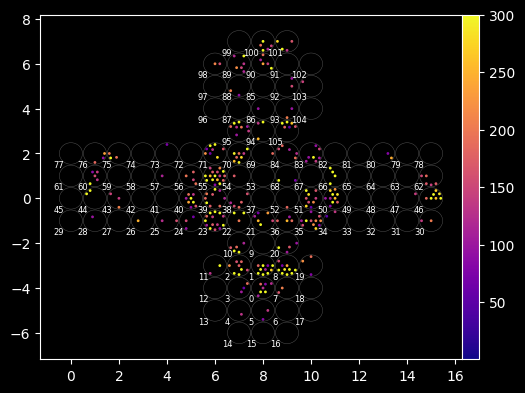

In [98]:
# Choose one event from the selected list.
evt_idx = 1
event_array = selection["events"][evt_idx]

# Try plotting the event (this is before any timing cuts to the evnt)
plot_event(event_array[:,0:2],evt_idx,vmax = 300)

In [99]:
out = fit_single_event(wcte_cfg, event=event_array)
summarize_result(out)

Loaded GOOD_WCTE_PMTS from: /eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/1580/WCTE_merged_production_R1580.root
LicketyFit single-event setup
  data_kind: wcte
  likelihood mode: charge_time
  fit particle: muon
  fit mode: full_length
  fit parameters: ('x0', 'y0', 'z0', 'cx', 'cy', 'length', 't0')
  fixed parameters: none
  number of seeds: 1547


{'data_kind': 'wcte',
 'fit_particle': 'muon',
 'fit_mode': 'full_length',
 'likelihood_mode': 'charge_time',
 'fcn': 614.1824948873591,
 'valid': False,
 'attempts': 1,
 'chosen_seed_idx': 323,
 'chosen_seed_fcn': 620.3202107433873,
 'x0': -10.265504257065627,
 'y0': -10.276204033286911,
 'z0': -1398.3737654005147,
 'cx': -0.0013374063746458445,
 'cy': 0.04073166779316844,
 'cz': 0.9991692261989338,
 't0': -0.07736979262161382,
 'visible_length_mm': 475.2232402862945,
 'full_range_mm': 475.2232402862945,
 'ke0_mev': 158.6432675667033,
 'n_observed_pes': 352.7762237762238,
 'n_expected_pes': 352.7762237762237}

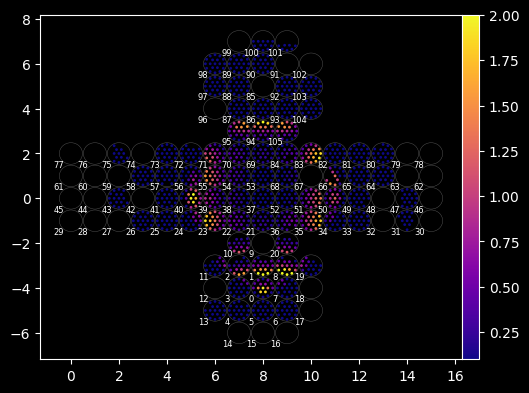

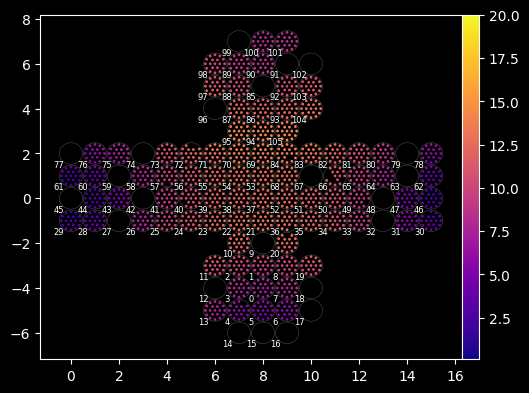

In [100]:
# Try plotting the expected PEs corresponding to the fit
plot_event(np.array([out['pmt_ids'],out['exp_pes']]).T,evt_idx,vmax = 2)
plot_event(np.array([out['pmt_ids'],out['exp_ts']]).T,evt_idx,vmax = 20)

In [83]:
out['exp_ts']

array([ 6.9991626 ,  6.99215277,  7.34230599, ..., 14.27253523,
       14.30578514, 14.50671516], shape=(1562,))

### Choosing a different selected event

After you have a `selection` object, changing events is cheap because you do not need to re-run the ROOT selection unless you want a different scan size or different cuts.


In [ ]:
selected_event_index = 0

if selected_event_index >= selection["n_selected"]:
    raise IndexError(
        f"selected_event_index={selected_event_index} but only "
        f"{selection['n_selected']} events passed cuts. Increase n_root_entries "
        "or choose a smaller selected-event index."
    )

event_array = selection["events"][selected_event_index]
out = fit_single_event(wcte_cfg, event=event_array)
summarize_result(out)


## 4. WCTE example: user-supplied event file

This is usually the fastest way to debug the fitter because you can hand it an already-selected event or a small collection of events.

Accepted WCTE event format:

```text
N_hits x 3 or N_hits x 4 array
column 0: WCTE PMT id = mPMT slot * 100 + PMT position
column 1: charge
column 2: calibrated hit time [ns]
column 3: optional event number, used only to split a concatenated 2D table
```

Accepted files: `.npy`, `.npz`, `.pkl`, `.pickle`. For `.npz` or dict payloads, keys named `events`, `data`, or `arr_0` are recognized automatically, or you can set `user_event_key`.

In [ ]:
# Example using a user file. Replace the path with your file.
wcte_file_cfg = SingleEventConfig(
    data_kind="wcte",
    event_index=0,
    event_source="file",
    user_event_file="/path/to/selected_events.npy",
    user_event_key=None,
    user_event_apply_peak_window=True,
    fit_particle="proton",
    fit_mode="absorption",
    likelihood_mode="charge_only",  # charge_only is often faster for first checks
    fixed_params={"ke0_mev": 1500.0},
    ncall_migrad=15000,
    max_fit_attempts=1,
    verbose=True,
)

# Uncomment to run:
# out = fit_single_event(wcte_file_cfg)
# summarize_result(out)

### Passing an event array directly

You can also bypass file loading entirely by passing `event=...` to `fit_single_event`. This is useful when you already have an event in memory.

In [ ]:
# Example only. Here event_array should have columns [pmt_id, charge, time].
# event_array = np.load("/path/to/one_event.npy", allow_pickle=True)

# out = fit_single_event(
#     SingleEventConfig(
#         data_kind="wcte",
#         fit_particle="proton",
#         fit_mode="absorption",
#         likelihood_mode="charge_only",
#         fixed_params={"ke0_mev": 1500.0},
#         ncall_migrad=15000,
#         max_fit_attempts=1,
#     ),
#     event=event_array,
# )
# summarize_result(out)

## 5. WCSim example

For WCSim, `fit_single_event.py` reuses the WCSim batch driver. You can either pass `wcsim_input_file` or pass a single event dictionary directly.

The event dictionary format is:

```python
{
    "digi_hit_pmt":    array_of_raw_or_wcte_pmt_ids,
    "digi_hit_time":   array_of_hit_times_ns,
    "digi_hit_charge": array_of_hit_charges_pe,
}
```

The PMT ID handling is controlled by `wcsim_pmt_id_mode`:

| Mode | Meaning |
|---|---|
| `"auto"` | use `tables/wcsim_wcte_mapping.txt` if found; otherwise assume WCTE IDs |
| `"mapping"` | require the mapping file |
| `"wcte"` | assume `digi_hit_pmt` already contains WCTE PMT IDs |

In [ ]:
wcsim_cfg = SingleEventConfig(
    data_kind="wcsim",
    wcsim_input_file="/path/to/wcsim_events.npz",
    event_index=0,
    energy_true=1000.0,
    fit_particle="proton",
    fit_mode="absorption",
    likelihood_mode="charge_time",
    fixed_params={
        "z0": -1350.0,
        "ke0_mev": 1000.0,
    },
    wcsim_pmt_id_mode="auto",
    ncall_migrad=20000,
    max_fit_attempts=2,
    save_top_n_seeds=10,
    verbose=True,
)

# Uncomment to run:
# out = fit_single_event(wcsim_cfg)
# summarize_result(out)

## 6. Inspecting the output

The output is a dictionary. The most useful entries are:

| Key | Meaning |
|---|---|
| `values` | best-fit parameter values |
| `errors` | Minuit parameter errors |
| `fval` | best final FCN/NLL |
| `result` | full result dictionary from the batch-driver helper |
| `obs_pes`, `obs_ts` | observed charge and charge-weighted time per PMT |
| `exp_pes`, `exp_ts` | expected charge and expected time per PMT from the fitted parameters |
| `pmt_ids` | PMT ID ordering corresponding to the PE/time arrays |
| `p_locations`, `direction_zs` | detector geometry arrays in the same PMT order |
| `initial_seeds` | seed grid used for this fit |
| `emitter_components` | component-level PE diagnostics when exposed by `Emitter` |

In [ ]:
# After running one of the cells above:
# summarize_result(out)

In [ ]:
# PMT-by-PMT diagnostic table.
# df = result_dataframe(out)
# df.head()

In [ ]:
# Quick observed-vs-expected charge plot.
# fig, ax = plot_observed_vs_expected(out, sort_by="pmt_id", log=False)
# plt.show()

## 7. Trying batch-driver configuration changes quickly

The point of the single-event wrapper is to test batch settings interactively. For example, compare charge-only and charge+time fits on the same event:

In [ ]:
# Example pattern; uncomment after choosing a real event source.
# cfg_charge = wcte_file_cfg
# cfg_joint = SingleEventConfig(**{**cfg_charge.__dict__, "likelihood_mode": "charge_time"})
#
# out_charge = fit_single_event(cfg_charge)
# out_joint = fit_single_event(cfg_joint)
#
# pd.DataFrame([summarize_result(out_charge), summarize_result(out_joint)])

You can also test fixed-parameter settings before committing to a batch run:

In [ ]:
# Example: fix the initial kinetic energy in absorption mode.
# cfg_fixed_ke = SingleEventConfig(
#     **{**wcte_file_cfg.__dict__,
#        "fixed_params": {"ke0_mev": 1500.0},
#        "likelihood_mode": "charge_only"}
# )
# out_fixed_ke = fit_single_event(cfg_fixed_ke)
# summarize_result(out_fixed_ke)

## 8. Speed tips for interactive use

For quick feedback, start with:

```python
likelihood_mode="charge_only"
ncall_migrad=10000 or 20000
max_fit_attempts=1
fast_seed_z0=[-1400.0, -1350.0, -1300.0]
fast_seed_visible_lengths=[300.0, 700.0, 1100.0, 1500.0]
fast_seed_ke0_mev=[1000.0, 1500.0]
```

Once the event and configuration behave sensibly, switch back toward the production settings used in the batch drivers.

In [ ]:
fast_debug_cfg = SingleEventConfig(
    data_kind="wcte",
    event_source="file",
    user_event_file="/path/to/selected_events.npy",
    event_index=0,
    fit_particle="proton",
    fit_mode="absorption",
    likelihood_mode="charge_only",
    fixed_params={"ke0_mev": 1500.0},
    fast_seed_z0=[-1400.0, -1350.0, -1300.0],
    fast_seed_visible_lengths=[300.0, 700.0, 1100.0, 1500.0],
    fast_seed_ke0_mev=[1000.0, 1500.0],
    ncall_migrad=10000,
    max_fit_attempts=1,
    save_top_n_seeds=5,
)

# out = fit_single_event(fast_debug_cfg)
# summarize_result(out)

## 9. Moving from notebook to batch driver

Once a single-event configuration looks good, transfer the same settings to the relevant batch driver:

| Notebook field | Batch-driver setting / environment variable |
|---|---|
| `fit_particle` | `FIT_PARTICLE` |
| `fit_mode` | `FIT_MODE` or `TRACK_END_MODE` |
| `likelihood_mode` | `LIKELIHOOD_MODE` or `FIT_TYPE` |
| `fixed_params={"z0": ...}` | `FIX_Z0` |
| `fixed_params={"ke0_mev": ...}` | `FIXED_KE0_MEV` or `FIX_KE0_MEV` |
| `fast_seed_visible_lengths` | `FAST_SEED_VISIBLE_LENGTHS` |
| `fast_seed_ke0_mev` | `FAST_SEED_KE0_MEV` |
| `ncall_migrad` | `NCALL_MIGRAD` |
| `max_fit_attempts` | `MAX_FIT_ATTEMPTS` |
| `fcn_retry_threshold` | `FCN_RETRY_THRESHOLD` |
| `ring_mask_mode` | `RING_MASK_MODE` |

Example batch command after testing in the notebook:

```bash
EVENT_SOURCE=file \
USER_EVENT_FILE=/path/to/selected_events.npy \
FIT_PARTICLE=proton \
FIT_MODE=absorption \
LIKELIHOOD_MODE=charge_time \
FIXED_KE0_MEV=1500 \
MAX_FIT_ATTEMPTS=4 \
NCALL_MIGRAD=70000 \
python scripts/batch_fit_driver_wcte.py
```